## Evaluation

### kid-friend

In [10]:
import pyterrier as pt
from pathlib import Path
from pyterrier.measures import RR, nDCG
from utils import get_ranked_lists
import pandas as pd


kf_queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")
kf_queries["qid"] = kf_queries["qid"].astype(str)

kf_results_dir = Path.cwd() / "results" / "kid-friend"
kf_results_dir.mkdir(exist_ok=True, parents=True)

qrels = [
    "relevance", 
    "readability", 
    "objectivity", 
    "edu"
]

for qrel in qrels:
    kf_qrel_file = pd.read_csv("../data/kid-friend-en/en/qrels/qrels-"+qrel+"-binary.csv")
    kf_qrel_file["qid"] = kf_qrel_file["qid"].astype(str)

    if qrel == "relevance":
        metrics = [RR @ 10, nDCG @ 10]
    else:
        metrics = [RR@10]
    
    kf_results = pt.Experiment(
        retr_systems = get_ranked_lists("results/kid-friend/"),
        topics = kf_queries,
        qrels = kf_qrel_file,
        names=["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"],
        eval_metrics=metrics,
        save_dir=str(kf_results_dir),
        save_mode='reuse', # switch to overwrite if required,
        baseline=0,
        correction='bonferroni'
    )
    
    kf_results.to_csv("results/kid-friend/"+qrel+"_eval.csv", index=False)
    print(qrel, "\n==============================================\n", kf_results, "\n==============================================\n\n")

relevance 
           name   nDCG@10     RR@10  nDCG@10 +  nDCG@10 -  nDCG@10 p-value  \
0         BM25  0.599215  0.763381        NaN        NaN              NaN   
1       TF-IDF  0.587289  0.743857        6.0        9.0         0.110887   
2  DirichletLM  0.583483  0.802889       20.0       25.0         0.387178   
3       MonoT5  0.643369  0.748167       29.0       17.0         0.150563   
4   RankVicuna  0.602107  0.779381        2.0        0.0         0.289728   
5   RankZephyr  0.643584  0.808667       29.0       17.0         0.160000   

   nDCG@10 reject  nDCG@10 p-value corrected  RR@10 +  RR@10 -  RR@10 p-value  \
0           False                        NaN      NaN      NaN            NaN   
1           False                   0.554436      1.0      2.0       0.170009   
2           False                   1.000000     10.0      7.0       0.294316   
3           False                   0.752817     11.0     11.0       0.751517   
4           False                   1.00000

In [11]:
import pyterrier as pt
from pathlib import Path
from pyterrier.measures import RR, nDCG
from utils import get_ranked_lists
import pandas as pd


kf_queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")
kf_queries["qid"] = kf_queries["qid"].astype(str)

kf_results_dir = Path.cwd() / "results" / "kid-friend"
kf_results_dir.mkdir(exist_ok=True, parents=True)

qrels = [
    "relevance", 
    "readability", 
    "objectivity", 
    "edu"
]

for qrel in qrels:
    kf_qrel_file = pd.read_csv("../data/kid-friend-en/en/qrels/qrels-"+qrel+"-binary.csv")
    kf_qrel_file["qid"] = kf_qrel_file["qid"].astype(str)

    if qrel == "relevance":
        metrics = [RR @ 10, nDCG @ 10]
    else:
        metrics = [RR@10]
    
    kf_results = pt.Experiment(
        retr_systems = get_ranked_lists("results/kid-friend/"),
        topics = kf_queries,
        qrels = kf_qrel_file,
        names=["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"],
        eval_metrics=metrics,
        save_dir=str(kf_results_dir),
        save_mode='reuse', # switch to overwrite if required,
        perquery=True
    )
    
    kf_results.to_csv("results/kid-friend/query_wise/"+qrel+"_eval.csv", index=False)
    print(qrel, "\n==============================================\n", kf_results, "\n==============================================\n\n")

relevance 
        name qid  measure     value
0      BM25   1  nDCG@10  0.138862
1      BM25   1    RR@10  0.500000
18     BM25  10  nDCG@10  0.397672
19     BM25  10    RR@10  0.500000
20     BM25  11  nDCG@10  0.680905
..      ...  ..      ...       ...
113  TF-IDF   7    RR@10  1.000000
114  TF-IDF   8  nDCG@10  0.243903
115  TF-IDF   8    RR@10  0.500000
116  TF-IDF   9  nDCG@10  0.188444
117  TF-IDF   9    RR@10  0.333333

[600 rows x 4 columns] 


readability 
       name qid measure     value
0     BM25   1   RR@10  0.000000
8     BM25  10   RR@10  0.500000
9     BM25  11   RR@10  1.000000
10    BM25  12   RR@10  1.000000
11    BM25  13   RR@10  0.333333
..     ...  ..     ...       ...
98  TF-IDF  50   RR@10  0.000000
55  TF-IDF   6   RR@10  0.166667
56  TF-IDF   7   RR@10  1.000000
99  TF-IDF   8   RR@10  0.000000
57  TF-IDF   9   RR@10  0.333333

[300 rows x 4 columns] 


objectivity 
       name qid measure     value
0     BM25   1   RR@10  0.500000
9     BM25  10   RR@10  

In [ ]:
import pyterrier as pt
from utils import RBP, get_ranked_lists
import pandas as pd


kf_retriever_systems = get_ranked_lists("results/kid-friend/")
kf_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# kf_retriever_systems = [kid_friend_tf_idf]
# kf_retriever_names = ["TF-IDF"]

kf_queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")
kf_queries["qid"] = kf_queries["qid"].astype(str)
kf_qrel_file = pd.read_csv("../data/kid-friend-en/en/qrels/qrels-relevance-binary.csv")
kf_qrel_file["qid"] = kf_qrel_file["qid"].astype(str)

kf_rbp_results = []
for sys, name in zip(kf_retriever_systems, kf_retriever_names):
    score = RBP(topics=kf_queries, qrels=kf_qrel_file, retriever_system=sys, phi=0.8, perquery=False, k=10)
    kf_rbp_results.append([name, score])

kf_rbp_results_df = pd.DataFrame(kf_rbp_results, columns=["name", f"RBP@10"])
kf_rbp_results_df

,name,RBP@10
0,BM25,0.540305
1,TF-IDF,0.536844
2,DirichletLM,0.527164
3,MonoT5,0.571840
4,RankVicuna,0.543076
5,RankZephyr,0.580468


In [5]:
import pyterrier as pt
from utils import RBP, get_ranked_lists
import pandas as pd


kf_retriever_systems = get_ranked_lists("results/kid-friend/")
kf_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# kf_retriever_systems = [kid_friend_tf_idf]
# kf_retriever_names = ["TF-IDF"]

kf_queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")
kf_queries["qid"] = kf_queries["qid"].astype(str)
kf_qrel_file = pd.read_csv("../data/kid-friend-en/en/qrels/qrels-relevance-binary.csv")
kf_qrel_file["qid"] = kf_qrel_file["qid"].astype(str)

kf_rbp_results = []
for sys, name in zip(kf_retriever_systems, kf_retriever_names):
    score = RBP(topics=kf_queries, qrels=kf_qrel_file, retriever_system=sys, phi=0.8, perquery=True, k=10)
    kf_rbp_results.append([name]+score)

kf_rbp_results_df_per_query = pd.DataFrame(kf_rbp_results, columns=["name"] + [f"RBP@10_q{i}" for i in range(1, len(score)+1)])
kf_rbp_results_df_per_query = kf_rbp_results_df_per_query.T
kf_rbp_results_df_per_query.columns = kf_rbp_results_df_per_query.iloc[0]
kf_rbp_results_df_per_query = kf_rbp_results_df_per_query.iloc[1:]
kf_rbp_results_df_per_query.to_csv("results/kid-friend/query_wise/RBP.csv", index=True)
kf_rbp_results_df_per_query.head()

name,BM25,TF-IDF,DirichletLM,MonoT5,RankVicuna,RankZephyr
RBP@10_q1,0.16,0.16,0.36,0.147456,0.16,0.169943
RBP@10_q2,0.052429,0.052429,0.033554,0.041943,0.052429,0.026844
RBP@10_q3,0.3024,0.3024,0.193536,0.18432,0.3024,0.367936
RBP@10_q4,0.0,0.0,0.0,0.0,0.0,0.0
RBP@10_q5,0.065536,0.065536,0.2,0.639519,0.065536,0.1024


In [ ]:
from scipy.stats import ttest_rel
import numpy as np
from statsmodels.stats.multitest import multipletests

RBP_pvals = [ttest_rel(np.array(kf_rbp_results_df_per_query["BM25"], dtype=float), np.array(kf_rbp_results_df_per_query[name], dtype=float)).pvalue for name in kf_retriever_names]
# RBP_pvals
bonf_correct_stats = multipletests(RBP_pvals, alpha=0.05, method='bonferroni', maxiter=1, is_sorted=False, returnsorted=False)
sig_df = pd.DataFrame(kf_retriever_names, columns=["name"])
sig_df["RBP@10 reject"] = bonf_correct_stats[0]
sig_df["RBP@10 corrected pval"] = bonf_correct_stats[1]
sig_df

,name,RBP@10 reject,RBP@10 corrected pval
0,BM25,False,NaN
1,TF-IDF,False,1.0
2,DirichletLM,False,1.0
3,MonoT5,False,1.0
4,RankVicuna,False,1.0
5,RankZephyr,False,1.0


In [ ]:
kf_rbp_results_df = kf_rbp_results_df.merge(sig_df, on="name")
kf_rbp_results_df

,name,RBP@10,RBP@10 reject,RBP@10 corrected pval
0,BM25,0.540305,False,NaN
1,TF-IDF,0.536844,False,1.0
2,DirichletLM,0.527164,False,1.0
3,MonoT5,0.571840,False,1.0
4,RankVicuna,0.543076,False,1.0
5,RankZephyr,0.580468,False,1.0


In [ ]:
import pyterrier as pt
from utils import cRBP, get_ranked_lists
import pandas as pd


kf_retriever_systems = get_ranked_lists("results/kid-friend/")
kf_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# kf_retriever_systems = [kid_friend_tf_idf]
# kf_retriever_names = ["TF-IDF"]

kf_queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")
kf_queries["qid"] = kf_queries["qid"].astype(str)
kf_qrel_file = pd.read_csv("../data/kid-friend-en/en/qrels/qrels-relevance-binary.csv")
kf_qrel_file["qid"] = kf_qrel_file["qid"].astype(str)
kf_corpus = pd.read_csv("../data/kid-friend-en/en/inputs/documents.csv")

kf_crbp_results = []
for sys, name in zip(kf_retriever_systems, kf_retriever_names):
    score = cRBP(topics=kf_queries, qrels=kf_qrel_file, corpus = kf_corpus, 
                 upper_threshold = 4, lower_threshold = 4, retriever_system=sys, phi=0.8, perquery=False, k=10)
    kf_crbp_results.append([name, score])

kf_crbp_results_df = pd.DataFrame(kf_crbp_results, columns=["name", f"cRBP@10"])
kf_crbp_results_df

,name,cRBP@10
0,BM25,0.064960
1,TF-IDF,0.065016
2,DirichletLM,0.064245
3,MonoT5,0.063446
4,RankVicuna,0.065190
5,RankZephyr,0.069812


In [6]:
import pyterrier as pt
from utils import cRBP, get_ranked_lists
import pandas as pd


kf_retriever_systems = get_ranked_lists("results/kid-friend/")
kf_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# kf_retriever_systems = [kid_friend_tf_idf]
# kf_retriever_names = ["TF-IDF"]

kf_queries = pd.read_csv("../data/kid-friend-en/en/inputs/topics.csv")
kf_queries["qid"] = kf_queries["qid"].astype(str)
kf_qrel_file = pd.read_csv("../data/kid-friend-en/en/qrels/qrels-relevance-binary.csv")
kf_qrel_file["qid"] = kf_qrel_file["qid"].astype(str)
kf_corpus = pd.read_csv("../data/kid-friend-en/en/inputs/documents.csv")

kf_crbp_results = []
for sys, name in zip(kf_retriever_systems, kf_retriever_names):
    score = cRBP(topics=kf_queries, qrels=kf_qrel_file, corpus = kf_corpus, 
                 upper_threshold = 4, lower_threshold = 4, retriever_system=sys, phi=0.8, perquery=True, k=10)
    kf_crbp_results.append([name]+score)

kf_crbp_results_df_per_query = pd.DataFrame(kf_crbp_results, columns=["name"] + [f"cRBP@10_q{i}" for i in range(1, len(score)+1)])
kf_crbp_results_df_per_query = kf_crbp_results_df_per_query.T
kf_crbp_results_df_per_query.columns = kf_crbp_results_df_per_query.iloc[0]
kf_crbp_results_df_per_query = kf_crbp_results_df_per_query.iloc[1:]
kf_crbp_results_df_per_query.to_csv("results/kid-friend/query_wise/cRBP.csv", index=True)
kf_crbp_results_df_per_query.head()

name,BM25,TF-IDF,DirichletLM,MonoT5,RankVicuna,RankZephyr
cRBP@10_q1,0.0,0.0,0.003532,0.001809,0.0,0.002826
cRBP@10_q2,0.0,0.0,0.0,0.0,0.0,0.0
cRBP@10_q3,0.0,0.0,0.0,0.0,0.0,0.0
cRBP@10_q4,0.0,0.0,0.0,0.0,0.0,0.0
cRBP@10_q5,0.0,0.0,0.004465,0.011203,0.0,0.0


In [ ]:
from scipy.stats import ttest_rel
import numpy as np
from statsmodels.stats.multitest import multipletests

cRBP_pvals = [ttest_rel(np.array(kf_crbp_results_df_per_query["BM25"], dtype=float), np.array(kf_crbp_results_df_per_query[name], dtype=float)).pvalue for name in kf_retriever_names]
# RBP_pvals
bonf_correct_stats = multipletests(cRBP_pvals, alpha=0.05, method='bonferroni', maxiter=1, is_sorted=False, returnsorted=False)
sig_df = pd.DataFrame(kf_retriever_names, columns=["name"])
sig_df["cRBP@10 reject"] = bonf_correct_stats[0]
sig_df["cRBP@10 corrected pval"] = bonf_correct_stats[1]
sig_df

,name,cRBP@10 reject,cRBP@10 corrected pval
0,BM25,False,NaN
1,TF-IDF,False,1.0
2,DirichletLM,False,1.0
3,MonoT5,False,1.0
4,RankVicuna,False,1.0
5,RankZephyr,False,1.0


In [ ]:
kf_crbp_results_df = kf_crbp_results_df.merge(sig_df, on="name")
kf_crbp_results_df

,name,cRBP@10,cRBP@10 reject,cRBP@10 corrected pval
0,BM25,0.064960,False,NaN
1,TF-IDF,0.065016,False,1.0
2,DirichletLM,0.064245,False,1.0
3,MonoT5,0.063446,False,1.0
4,RankVicuna,0.065190,False,1.0
5,RankZephyr,0.069812,False,1.0


In [ ]:
kf_rbp_results = kf_rbp_results_df.merge(kf_crbp_results_df, on="name")
kf_rbp_results.to_csv("results/kid-friend/rbp_eval.csv", index=False)
kf_rbp_results

,name,RBP@10,RBP@10 reject,RBP@10 corrected pval,cRBP@10,cRBP@10 reject,cRBP@10 corrected pval
0,BM25,0.540305,False,NaN,0.064960,False,NaN
1,TF-IDF,0.536844,False,1.0,0.065016,False,1.0
2,DirichletLM,0.527164,False,1.0,0.064245,False,1.0
3,MonoT5,0.571840,False,1.0,0.063446,False,1.0
4,RankVicuna,0.543076,False,1.0,0.065190,False,1.0
5,RankZephyr,0.580468,False,1.0,0.069812,False,1.0


### requik

In [2]:
import pyterrier as pt
from pathlib import Path
from pyterrier.measures import RR, nDCG
from utils import get_ranked_lists
import pandas as pd

requik_queries = pd.read_csv("../data/requik/inputs/topics.csv")
requik_queries["qid"] = requik_queries["qid"].astype(str)

requik_results_dir = Path.cwd() / "results" / "requik"
requik_results_dir.mkdir(exist_ok=True, parents=True)

qrels = [
    "relevance", 
    "readability", 
    "objectivity", 
    "edu"
]

for qrel in qrels:

    requik_qrel_file = pd.read_csv("../data/requik/qrels/qrels-"+qrel+"-binary.csv")
    requik_qrel_file["qid"] = requik_qrel_file["qid"].astype(str)

    if qrel == "relevance":
        metrics = [RR @ 10, nDCG @ 10]
    else:
        metrics = [RR@10]
    
    requik_results = pt.Experiment(
        retr_systems = get_ranked_lists("results/requik/"),
        topics = requik_queries,
        qrels = requik_qrel_file,
        names=["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"],
        eval_metrics= metrics,
        save_dir=str(requik_results_dir),
        save_mode='reuse', # switch to overwrite if required
        baseline=0,
        correction='bonferroni'
    )
    
    requik_results.to_csv("results/requik/"+qrel+"_eval.csv", index=False)
    print(qrel, "\n==============================================\n", requik_results, "\n==============================================\n\n")    

relevance 
           name   nDCG@10     RR@10  nDCG@10 +  nDCG@10 -  nDCG@10 p-value  \
0         BM25  0.329358  0.277279        NaN        NaN              NaN   
1       TF-IDF  0.329534  0.277449        1.0        0.0         0.320289   
2  DirichletLM  0.359240  0.296283       15.0       13.0         0.114562   
3       MonoT5  0.341833  0.277671       18.0       20.0         0.656971   
4   RankVicuna  0.277067  0.215239        8.0       27.0         0.009322   
5   RankZephyr  0.288493  0.208416       16.0       25.0         0.124025   

   nDCG@10 reject  nDCG@10 p-value corrected  RR@10 +  RR@10 -  RR@10 p-value  \
0           False                        NaN      NaN      NaN            NaN   
1           False                   1.000000      1.0      0.0       0.320289   
2           False                   0.572808     14.0     13.0       0.296129   
3           False                   1.000000     17.0     20.0       0.990299   
4            True                   0.04660

In [12]:
import pyterrier as pt
from pathlib import Path
from pyterrier.measures import RR, nDCG
from utils import get_ranked_lists
import pandas as pd

requik_queries = pd.read_csv("../data/requik/inputs/topics.csv")
requik_queries["qid"] = requik_queries["qid"].astype(str)

requik_results_dir = Path.cwd() / "results" / "requik"
requik_results_dir.mkdir(exist_ok=True, parents=True)

qrels = [
    "relevance", 
    "readability", 
    "objectivity", 
    "edu"
]

for qrel in qrels:

    requik_qrel_file = pd.read_csv("../data/requik/qrels/qrels-"+qrel+"-binary.csv")
    requik_qrel_file["qid"] = requik_qrel_file["qid"].astype(str)

    if qrel == "relevance":
        metrics = [RR @ 10, nDCG @ 10]
    else:
        metrics = [RR@10]
    
    requik_results = pt.Experiment(
        retr_systems = get_ranked_lists("results/requik/"),
        topics = requik_queries,
        qrels = requik_qrel_file,
        names=["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"],
        eval_metrics= metrics,
        save_dir=str(requik_results_dir),
        save_mode='reuse', # switch to overwrite if required
        perquery=True
    )
    
    requik_results.to_csv("results/requik/query_wise/"+qrel+"_eval.csv", index=False)
    print(qrel, "\n==============================================\n", requik_results, "\n==============================================\n\n")    

relevance 
        name    qid  measure    value
0      BM25   RQq1  nDCG@10  1.00000
1      BM25   RQq1    RR@10  1.00000
2      BM25  RQq10  nDCG@10  0.63093
3      BM25  RQq10    RR@10  0.50000
4      BM25  RQq11  nDCG@10  0.00000
..      ...    ...      ...      ...
321  TF-IDF  RQq81    RR@10  0.25000
322  TF-IDF  RQq82  nDCG@10  0.00000
323  TF-IDF  RQq82    RR@10  0.00000
324  TF-IDF   RQq9  nDCG@10  1.00000
325  TF-IDF   RQq9    RR@10  1.00000

[984 rows x 4 columns] 


readability 
        name    qid measure     value
0      BM25   RQq1   RR@10  1.000000
1      BM25  RQq10   RR@10  0.500000
2      BM25  RQq11   RR@10  0.000000
3      BM25  RQq12   RR@10  0.142857
65     BM25  RQq13   RR@10  0.000000
..      ...    ...     ...       ...
142  TF-IDF   RQq8   RR@10  1.000000
143  TF-IDF  RQq80   RR@10  0.500000
144  TF-IDF  RQq81   RR@10  0.250000
145  TF-IDF  RQq82   RR@10  0.000000
146  TF-IDF   RQq9   RR@10  1.000000

[492 rows x 4 columns] 


objectivity 
        name    qid

In [1]:
import pyterrier as pt
from utils import RBP, get_ranked_lists
import pandas as pd


requik_retriever_systems = get_ranked_lists("results/requik/")
requik_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# requik_retriever_systems = [requik_tf_idf]
# requik_retriever_names = ["TF-IDF"]

requik_queries = pd.read_csv("../data/requik/inputs/topics.csv")
requik_queries["qid"] = requik_queries["qid"].astype(str)
requik_qrel = pd.read_csv("../data/requik/qrels/qrels-relevance-binary.csv")
requik_qrel["qid"] = requik_qrel["qid"].astype(str)

requik_rbp_results = []
for sys, name in zip(requik_retriever_systems, requik_retriever_names):
    score = RBP(topics=requik_queries, qrels=requik_qrel, retriever_system=sys, phi=0.8, perquery=False, k=10)
    requik_rbp_results.append([name, score])

requik_rbp_results_df = pd.DataFrame(requik_rbp_results, columns=["name", f"RBP@10"])
requik_rbp_results_df

,name,RBP@10
0,BM25,0.072257
1,TF-IDF,0.072359
2,DirichletLM,0.078922
3,MonoT5,0.075462
4,RankVicuna,0.060729
5,RankZephyr,0.063078


In [7]:
import pyterrier as pt
from utils import RBP, get_ranked_lists
import pandas as pd


requik_retriever_systems = get_ranked_lists("results/requik/")
requik_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# requik_retriever_systems = [requik_tf_idf]
# requik_retriever_names = ["TF-IDF"]

requik_queries = pd.read_csv("../data/requik/inputs/topics.csv")
requik_queries["qid"] = requik_queries["qid"].astype(str)
requik_qrel = pd.read_csv("../data/requik/qrels/qrels-relevance-binary.csv")
requik_qrel["qid"] = requik_qrel["qid"].astype(str)

requik_rbp_results = []
for sys, name in zip(requik_retriever_systems, requik_retriever_names):
    score = RBP(topics=requik_queries, qrels=requik_qrel, retriever_system=sys, phi=0.8, perquery=True, k=10)
    requik_rbp_results.append([name] + score)

requik_rbp_results_df_per_query = pd.DataFrame(requik_rbp_results, columns=["name"] + [f"RBP@10_q{i}" for i in range(1, len(score)+1)])
requik_rbp_results_df_per_query = requik_rbp_results_df_per_query.T
requik_rbp_results_df_per_query.columns = requik_rbp_results_df_per_query.iloc[0]
requik_rbp_results_df_per_query = requik_rbp_results_df_per_query.iloc[1:]
requik_rbp_results_df_per_query.to_csv("results/requik/query_wise/RBP.csv", index=True)
requik_rbp_results_df_per_query.head()

name,BM25,TF-IDF,DirichletLM,MonoT5,RankVicuna,RankZephyr
RBP@10_q1,0.2,0.2,0.2,0.2,0.2,0.2
RBP@10_q2,0.065536,0.065536,0.052429,0.052429,0.08192,0.065536
RBP@10_q3,0.0,0.0,0.0,0.026844,0.026844,0.026844
RBP@10_q4,0.1024,0.1024,0.0,0.128,0.08192,0.16
RBP@10_q5,0.128,0.128,0.2,0.052429,0.1024,0.0


In [3]:
from scipy.stats import ttest_rel
import numpy as np
from statsmodels.stats.multitest import multipletests

RBP_pvals = [ttest_rel(np.array(requik_rbp_results_df_per_query["BM25"], dtype=float), np.array(requik_rbp_results_df_per_query[name], dtype=float)).pvalue for name in requik_retriever_names]
# RBP_pvals
bonf_correct_stats = multipletests(RBP_pvals, alpha=0.05, method='bonferroni', maxiter=1, is_sorted=False, returnsorted=False)
sig_df = pd.DataFrame(requik_retriever_names, columns=["name"])
sig_df["RBP@10 reject"] = bonf_correct_stats[0]
sig_df["RBP@10 corrected pval"] = bonf_correct_stats[1]
sig_df

,name,RBP@10 reject,RBP@10 corrected pval
0,BM25,False,NaN
1,TF-IDF,False,1.000000
2,DirichletLM,False,0.825419
3,MonoT5,False,1.000000
4,RankVicuna,True,0.027286
5,RankZephyr,False,0.617060


In [4]:
requik_rbp_results_df = requik_rbp_results_df.merge(sig_df, on="name")
requik_rbp_results_df

,name,RBP@10,RBP@10 reject,RBP@10 corrected pval
0,BM25,0.072257,False,NaN
1,TF-IDF,0.072359,False,1.000000
2,DirichletLM,0.078922,False,0.825419
3,MonoT5,0.075462,False,1.000000
4,RankVicuna,0.060729,True,0.027286
5,RankZephyr,0.063078,False,0.617060


In [5]:
import pyterrier as pt
from utils import cRBP, get_ranked_lists
import pandas as pd


requik_retriever_systems = get_ranked_lists("results/requik/")
requik_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# requik_retriever_systems = [requik_tf_idf]
# requik_retriever_names = ["TF-IDF"]

requik_queries = pd.read_csv("../data/requik/inputs/topics.csv")
requik_queries["qid"] = requik_queries["qid"].astype(str)
requik_qrel = pd.read_csv("../data/requik/qrels/qrels-relevance-binary.csv")
requik_qrel["qid"] = requik_qrel["qid"].astype(str)
requik_corpus = pd.read_csv("../data/requik/inputs/documents.csv")

requik_crbp_results = []
for sys, name in zip(requik_retriever_systems, requik_retriever_names):
    score = cRBP(topics=requik_queries, qrels=requik_qrel, corpus = requik_corpus, upper_threshold = 5, lower_threshold = 3, 
                 retriever_system=sys, phi=0.8, perquery=False, k=10)
    requik_crbp_results.append([name, score])

requik_crbp_results_df = pd.DataFrame(requik_crbp_results, columns=["name", f"cRBP@10"])
requik_crbp_results_df

,name,cRBP@10
0,BM25,0.008077
1,TF-IDF,0.008077
2,DirichletLM,0.008876
3,MonoT5,0.008523
4,RankVicuna,0.007515
5,RankZephyr,0.007734


In [8]:
import pyterrier as pt
from utils import cRBP, get_ranked_lists
import pandas as pd


requik_retriever_systems = get_ranked_lists("results/requik/")
requik_retriever_names = ["BM25", "TF-IDF", "DirichletLM", "MonoT5", "RankVicuna", "RankZephyr"]

# requik_retriever_systems = [requik_tf_idf]
# requik_retriever_names = ["TF-IDF"]

requik_queries = pd.read_csv("../data/requik/inputs/topics.csv")
requik_queries["qid"] = requik_queries["qid"].astype(str)
requik_qrel = pd.read_csv("../data/requik/qrels/qrels-relevance-binary.csv")
requik_qrel["qid"] = requik_qrel["qid"].astype(str)
requik_corpus = pd.read_csv("../data/requik/inputs/documents.csv")

requik_crbp_results = []
for sys, name in zip(requik_retriever_systems, requik_retriever_names):
    score = cRBP(topics=requik_queries, qrels=requik_qrel, corpus = requik_corpus, upper_threshold = 5, lower_threshold = 3, 
                 retriever_system=sys, phi=0.8, perquery=True, k=10)
    requik_crbp_results.append([name] + score)

requik_crbp_results_df_per_query = pd.DataFrame(requik_crbp_results, columns=["name"] + [f"cRBP@10_q{i}" for i in range(1, len(score)+1)])
requik_crbp_results_df_per_query = requik_crbp_results_df_per_query.T
requik_crbp_results_df_per_query.columns = requik_crbp_results_df_per_query.iloc[0]
requik_crbp_results_df_per_query = requik_crbp_results_df_per_query.iloc[1:]
requik_crbp_results_df_per_query.to_csv("results/requik/query_wise/cRBP.csv", index=True)
requik_crbp_results_df_per_query.head()

name,BM25,TF-IDF,DirichletLM,MonoT5,RankVicuna,RankZephyr
cRBP@10_q1,0.03471,0.03471,0.03471,0.03471,0.03471,0.03471
cRBP@10_q2,0.036408,0.036408,0.029126,0.029126,0.04551,0.036408
cRBP@10_q3,0.0,0.0,0.0,0.010072,0.010072,0.010072
cRBP@10_q4,0.034478,0.034478,0.0,0.043098,0.027583,0.053872
cRBP@10_q5,0.017004,0.017004,0.026569,0.006965,0.013603,0.0


In [7]:
from scipy.stats import ttest_rel
import numpy as np
from statsmodels.stats.multitest import multipletests

cRBP_pvals = [ttest_rel(np.array(requik_crbp_results_df_per_query["BM25"], dtype=float), np.array(requik_crbp_results_df_per_query[name], dtype=float)).pvalue for name in requik_retriever_names]
# RBP_pvals
bonf_correct_stats = multipletests(cRBP_pvals, alpha=0.05, method='bonferroni', maxiter=1, is_sorted=False, returnsorted=False)
sig_df = pd.DataFrame(requik_retriever_names, columns=["name"])
sig_df["cRBP@10 reject"] = bonf_correct_stats[0]
sig_df["cRBP@10 corrected pval"] = bonf_correct_stats[1]
sig_df

,name,cRBP@10 reject,cRBP@10 corrected pval
0,BM25,False,NaN
1,TF-IDF,False,NaN
2,DirichletLM,False,1.000000
3,MonoT5,False,1.000000
4,RankVicuna,False,0.556026
5,RankZephyr,False,1.000000


In [8]:
requik_crbp_results_df = requik_crbp_results_df.merge(sig_df, on="name")
requik_crbp_results_df

,name,cRBP@10,cRBP@10 reject,cRBP@10 corrected pval
0,BM25,0.008077,False,NaN
1,TF-IDF,0.008077,False,NaN
2,DirichletLM,0.008876,False,1.000000
3,MonoT5,0.008523,False,1.000000
4,RankVicuna,0.007515,False,0.556026
5,RankZephyr,0.007734,False,1.000000


In [9]:
requik_rbp_results = requik_rbp_results_df.merge(requik_crbp_results_df, on="name")
requik_rbp_results.to_csv("results/requik/rbp_eval.csv", index=False)
requik_rbp_results

,name,RBP@10,RBP@10 reject,RBP@10 corrected pval,cRBP@10,cRBP@10 reject,cRBP@10 corrected pval
0,BM25,0.072257,False,NaN,0.008077,False,NaN
1,TF-IDF,0.072359,False,1.000000,0.008077,False,NaN
2,DirichletLM,0.078922,False,0.825419,0.008876,False,1.000000
3,MonoT5,0.075462,False,1.000000,0.008523,False,1.000000
4,RankVicuna,0.060729,True,0.027286,0.007515,False,0.556026
5,RankZephyr,0.063078,False,0.617060,0.007734,False,1.000000


## Consolidating Results

In [ ]:
import pandas as pd

kf_rel_eval = pd.read_csv("results/kid-friend/relevance_eval.csv")[["name", "nDCG@10", "RR@10"]]
kf_read_eval = pd.read_csv("results/kid-friend/readability_eval.csv")[["name", "RR@10"]].rename({"RR@10": "RR(read)@10"}, axis=1)
kf_edu_eval = pd.read_csv("results/kid-friend/edu_eval.csv")[["name", "RR@10"]].rename({"RR@10": "RR(edu)@10"}, axis=1)
kf_obj_eval = pd.read_csv("results/kid-friend/objectivity_eval.csv")[["name", "RR@10"]].rename({"RR@10": "RR(obj)@10"}, axis=1)
kf_rbp_eval = pd.read_csv("results/kid-friend/rbp_eval.csv")[["name", "RBP@10", "cRBP@10"]]
kf_eval = kf_rel_eval.merge(kf_read_eval, on="name")
kf_eval = kf_eval.merge(kf_edu_eval, on="name")
kf_eval = kf_eval.merge(kf_obj_eval, on="name")
kf_eval = kf_eval.merge(kf_rbp_eval, on="name")
kf_eval = kf_eval[["name", "nDCG@10", "RBP@10", "RR@10", "RR(read)@10", "RR(edu)@10", "RR(obj)@10", "cRBP@10"]]
kf_eval.to_csv("results/kid-friend/eval_consolidated.csv", index=False)
kf_eval

,name,nDCG@10,RBP@10,RR@10,RR(read)@10,RR(edu)@10,RR(obj)@10,cRBP@10
0,BM25,0.599215,0.540305,0.763381,0.493048,0.198889,0.671190,0.064960
1,TF-IDF,0.587289,0.536844,0.743857,0.469190,0.198889,0.670000,0.065016
2,DirichletLM,0.583483,0.527164,0.802889,0.476556,0.200333,0.678833,0.064245
3,MonoT5,0.643369,0.571840,0.748167,0.496278,0.162111,0.644333,0.063446
4,RankVicuna,0.602107,0.543076,0.779381,0.509048,0.198889,0.671190,0.065190
5,RankZephyr,0.643584,0.580468,0.808667,0.498802,0.176024,0.661667,0.069812


In [26]:
from scipy.stats import kendalltau

kendalltau(kf_eval["nDCG@10"], kf_eval["cRBP@10"])

SignificanceResult(statistic=np.float64(0.3333333333333333), pvalue=np.float64(0.46944444444444444))

In [30]:
kendalltau(kf_eval["nDCG@10"], kf_eval["RR@10"])

SignificanceResult(statistic=np.float64(0.2), pvalue=np.float64(0.7194444444444444))

In [31]:
kendalltau(kf_eval["nDCG@10"], kf_eval["RBP@10"])

SignificanceResult(statistic=np.float64(0.9999999999999999), pvalue=np.float64(0.002777777777777778))

In [ ]:
import pandas as pd

requik_rel_eval = pd.read_csv("results/requik/relevance_eval.csv")[["name", "nDCG@10", "RR@10"]]
requik_read_eval = pd.read_csv("results/requik/readability_eval.csv")[["name", "RR@10"]].rename({"RR@10": "RR(read)@10"}, axis=1)
requik_edu_eval = pd.read_csv("results/requik/edu_eval.csv")[["name", "RR@10"]].rename({"RR@10": "RR(edu)@10"}, axis=1)
requik_obj_eval = pd.read_csv("results/requik/objectivity_eval.csv")[["name", "RR@10"]].rename({"RR@10": "RR(obj)@10"}, axis=1)
requik_rbp_eval = pd.read_csv("results/requik/rbp_eval.csv")[["name", "RBP@10", "cRBP@10"]]

requik_eval = requik_rel_eval.merge(requik_read_eval, on="name")
requik_eval = requik_eval.merge(requik_edu_eval, on="name")
requik_eval = requik_eval.merge(requik_obj_eval, on="name")
requik_eval = requik_eval.merge(requik_rbp_eval, on="name")
requik_eval = requik_eval[["name", "nDCG@10", "RBP@10", "RR@10", "RR(read)@10", "RR(edu)@10", "RR(obj)@10", "cRBP@10"]]

requik_eval.to_csv("results/requik/eval_consolidated.csv", index=False)
requik_eval

,name,nDCG@10,RBP@10,RR@10,RR(read)@10,RR(edu)@10,RR(obj)@10,cRBP@10
0,BM25,0.329358,0.072257,0.277279,0.213966,0.002033,0.185172,0.008077
1,TF-IDF,0.329534,0.072359,0.277449,0.214136,0.002033,0.185342,0.008077
2,DirichletLM,0.359240,0.078922,0.296283,0.234142,0.001742,0.207515,0.008876
3,MonoT5,0.341833,0.075462,0.277671,0.235497,0.002962,0.163187,0.008523
4,RankVicuna,0.277067,0.060729,0.215239,0.188782,0.003659,0.129452,0.007515
5,RankZephyr,0.288493,0.063078,0.208416,0.177996,0.003252,0.114107,0.007734


In [27]:
from scipy.stats import kendalltau

kendalltau(requik_eval["nDCG@10"], requik_eval["cRBP@10"])

SignificanceResult(statistic=np.float64(0.9660917830792959), pvalue=np.float64(0.007410254402604282))

In [29]:
kendalltau(requik_eval["nDCG@10"], requik_eval["RR@10"])

SignificanceResult(statistic=np.float64(0.8666666666666666), pvalue=np.float64(0.016666666666666666))

In [32]:
kendalltau(requik_eval["nDCG@10"], requik_eval["RBP@10"])

SignificanceResult(statistic=np.float64(0.9999999999999999), pvalue=np.float64(0.002777777777777778))

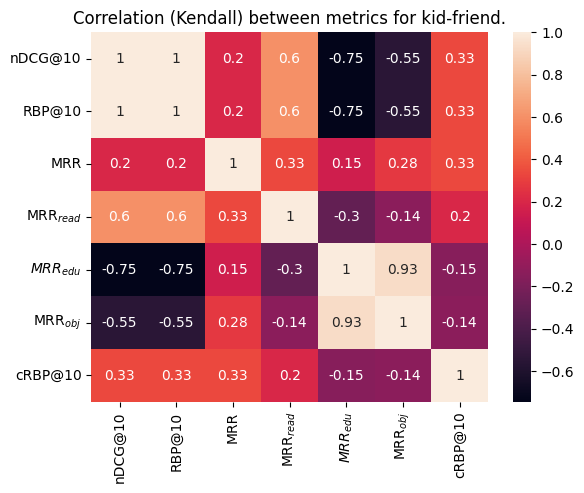

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# load the Auto dataset
kf_results = pd.read_csv("results/kid-friend/eval_consolidated.csv")
kf_results = kf_results.rename({"RR@10": "MRR", "RR(read)@10": "MRR$_{read}$", "RR(edu)@10": "$MRR_{edu}$", "RR(obj)@10":"MRR$_{obj}$"}, axis=1)

# calculate the correlation matrix on the numeric columns
kf_corr = kf_results.select_dtypes('number').corr(method="kendall")

# plot the heatmap
f = sns.heatmap(kf_corr, annot=True)
plt.title("Correlation (Kendall) between metrics for kid-friend.")
plt.show()

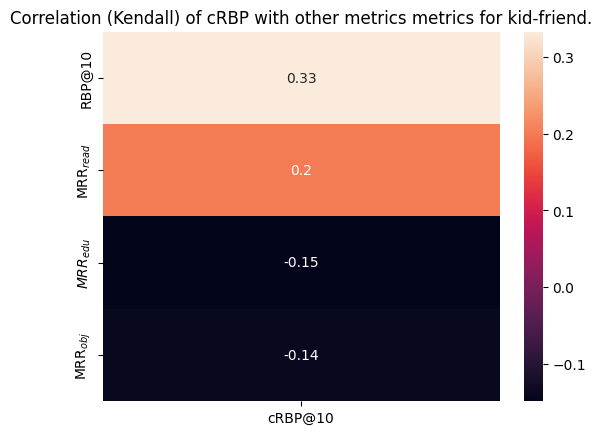

In [43]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# load the Auto dataset
kf_results = pd.read_csv("results/kid-friend/eval_consolidated.csv")
kf_results = kf_results.rename({"RR@10": "MRR", "RR(read)@10": "MRR$_{read}$", "RR(edu)@10": "$MRR_{edu}$", "RR(obj)@10":"MRR$_{obj}$"}, axis=1)


# calculate the correlation matrix on the numeric columns
kf_corr = kf_results.select_dtypes('number').corr(method="kendall")

# plot the heatmap
f = sns.heatmap(kf_corr[["cRBP@10"]].drop(["nDCG@10", "MRR", "cRBP@10"], axis=0), annot=True)
plt.title("Correlation (Kendall) of cRBP with other metrics metrics for kid-friend.")
plt.show()

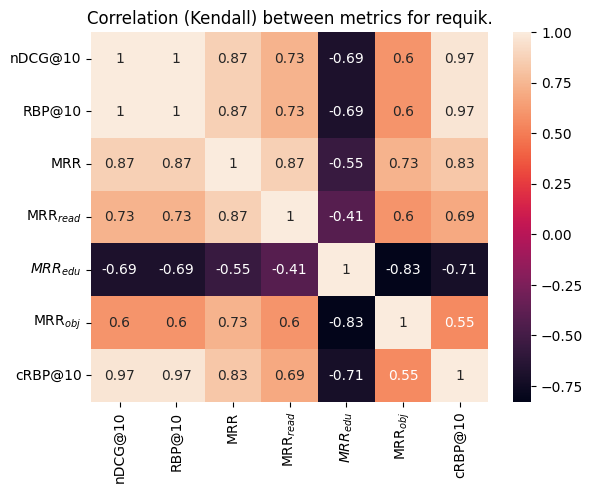

In [44]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# load the Auto dataset
requik_results = pd.read_csv("results/requik/eval_consolidated.csv")
requik_results = requik_results.rename({"RR@10": "MRR", "RR(read)@10": "MRR$_{read}$", "RR(edu)@10": "$MRR_{edu}$", "RR(obj)@10":"MRR$_{obj}$"}, axis=1)

# calculate the correlation matrix on the numeric columns
requik_corr = requik_results.select_dtypes('number').corr(method="kendall")

# plot the heatmap
f = sns.heatmap(requik_corr, annot=True)
plt.title("Correlation (Kendall) between metrics for requik.")
plt.show()

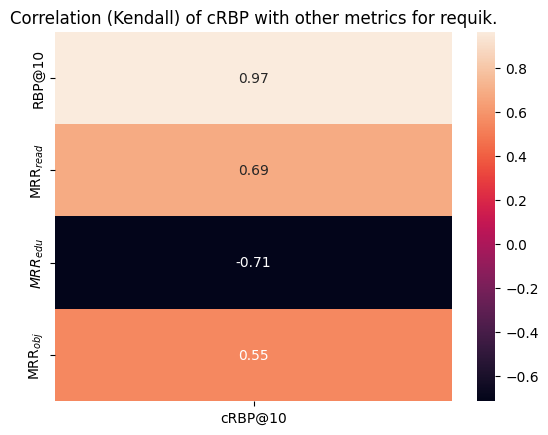

In [46]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# load the Auto dataset
requik_results = pd.read_csv("results/requik/eval_consolidated.csv")
requik_results = requik_results.rename({"RR@10": "MRR", "RR(read)@10": "MRR$_{read}$", "RR(edu)@10": "$MRR_{edu}$", "RR(obj)@10":"MRR$_{obj}$"}, axis=1)

# calculate the correlation matrix on the numeric columns
requik_corr = requik_results.select_dtypes('number').corr(method="kendall")

# plot the heatmap
f = sns.heatmap(requik_corr[["cRBP@10"]].drop(["nDCG@10", "MRR", "cRBP@10"], axis=0), annot=True)
plt.title("Correlation (Kendall) of cRBP with other metrics for requik.")
plt.show()

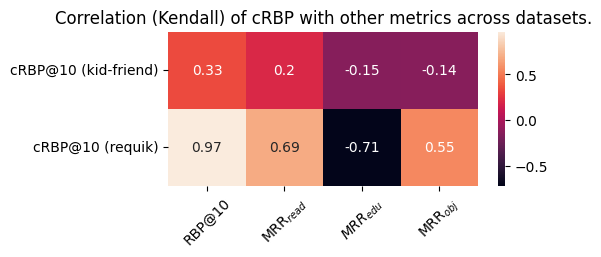

In [49]:
fig, ax = plt.subplots(figsize=(5, 2))
kf_corr_crbp = kf_corr[["cRBP@10"]].drop(["nDCG@10", "MRR", "cRBP@10"], axis=0).rename({"cRBP@10":"cRBP@10 (kid-friend)"}, axis=1)
requik_corr_crbp = requik_corr[["cRBP@10"]].drop(["nDCG@10", "MRR", "cRBP@10"], axis=0).rename({"cRBP@10":"cRBP@10 (requik)"}, axis=1)
merged_corrs = kf_corr_crbp.join(requik_corr_crbp)
f = sns.heatmap(merged_corrs.T, annot=True, ax=ax)
plt.title("Correlation (Kendall) of cRBP with other metrics across datasets.")
ax.tick_params(axis='x', rotation=45)
plt.show()